In [1]:
import os
import random
import time

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)
import tensorflow as tf
from tensorflow.keras import models, Sequential, applications, layers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger,
    ReduceLROnPlateau
)
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.utils import image_dataset_from_directory
import keras_tuner as kt

In [2]:
TRAIN_DATA_PATH = "../affectnet_dataset/Train"
TEST_DATA_PATH = "../affectnet_dataset/Test"
EPOCHS = 100
RANDOM_SEED = 40
BATCH_SIZE = 32
IMG_SIZE = (96,96)

SAVED_MODEL = "../saved_models/transfer_kt_model.keras"


In [3]:
# Set global random seeds for reproducibility
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

In [4]:
'''
flow_from_directory is older approach - slower
used image_dataset_from_directory instead for better performance and easier handling of validation split
'''

train_dataset = image_dataset_from_directory(
    TRAIN_DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed = RANDOM_SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode = "int",
    shuffle=True
)

val_dataset = image_dataset_from_directory(
    TRAIN_DATA_PATH,
    validation_split=0.2,
    seed = RANDOM_SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode = "int",
    subset="validation",
)

test_dataset = image_dataset_from_directory(
    TEST_DATA_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode = "int"
)

Found 16108 files belonging to 8 classes.
Using 12887 files for training.
Found 16108 files belonging to 8 classes.
Using 3221 files for validation.
Found 14518 files belonging to 8 classes.


In [5]:
train_counts = {}
CLASSES = train_dataset.class_names
num_classes = len(CLASSES)

for cls in CLASSES:
    cls_folder = os.path.join(TRAIN_DATA_PATH, cls)
    train_counts[cls] = len(os.listdir(cls_folder))

print(train_counts)


{'anger': 1500, 'contempt': 1559, 'disgust': 1229, 'fear': 1512, 'happy': 2340, 'neutral': 2758, 'sad': 3091, 'surprise': 2119}


In [6]:
'''
Compute class weights from train splitted part only (imbalanced data)
- train_labels is an array of all labels from train dataset.
- concetenate() is used to combine all batches of labels into array
for class weight computation
- y.numpy() is used to convert tensor to numpy array for class weight computation
Class weights змушують loss сильніше штрафувати помилки на rare classes.
'''

train_labels = np.concatenate([y.numpy() for _, y in train_dataset], axis=0)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=train_labels
)
class_weights = dict(enumerate(class_weights_array))

print("Class names:", CLASSES)
print("Class weights:", class_weights)

Class names: ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Class weights: {0: np.float64(1.3480125523012552), 1: np.float64(1.2887), 2: np.float64(1.6287917087967645), 3: np.float64(1.3525398824517212), 4: np.float64(0.8642033261802575), 5: np.float64(0.7328821656050956), 6: np.float64(0.643063872255489), 7: np.float64(0.9503687315634218)}


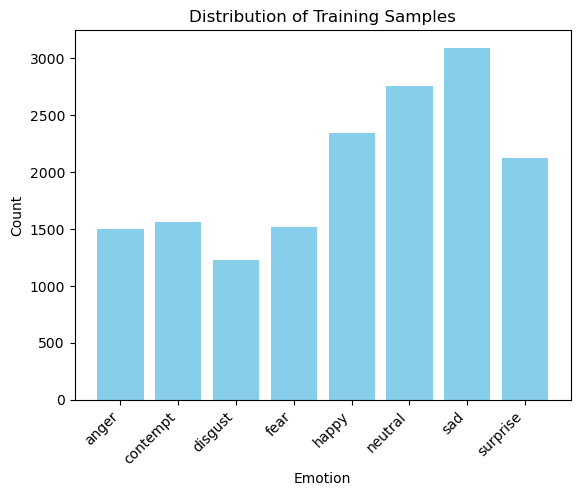

In [7]:
plt.bar(train_counts.keys(), train_counts.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.title('Distribution of Training Samples')
plt.show()

In [8]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal", seed=RANDOM_SEED),
    layers.RandomRotation(0.05, seed=RANDOM_SEED), # 0.1
    layers.RandomZoom(0.05, seed=RANDOM_SEED),
], name="data_augmentation")

In [9]:
base_model = applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False, # rm last classification block
    weights = "imagenet" # take weights pretrained on imagenet
)
# Freeze base block
base_model.trainable = False

In [10]:
print(base_model.name)
print(base_model.trainable)

mobilenetv2_1.00_96
False


In [11]:
# Functional API for more flexibility in architecture and hp tuning
def build_model(hp):
    dropout = hp.Float("dropout", 0.2, 0.5, step=0.1)

    dense_units1 = hp.Choice("dense_units1", [128, 256, 512])
    dense_units2 = hp.Choice("dense_units2", [128, 256, 512])

    l2 = hp.Float("l2_3", 1e-5, 1e-3, sampling="log")
    lr = hp.Float("lr", 1e-4, 1e-3, sampling="log")

    model = Sequential([    
        layers.Input(shape=(*IMG_SIZE, 3)),
        data_augmentation,
        layers.Rescaling(scale=1./127/5, offset=-1),
        base_model,
        layers.GlobalAveragePooling2D(),

        layers.Dense(
            dense_units1,
            kernel_regularizer=tf.keras.regularizers.l2(l2)
            ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(dropout),

        layers.Dense(
            dense_units2,
            kernel_regularizer=tf.keras.regularizers.l2(l2)
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(dropout),

        layers.Dense(num_classes, activation='softmax'),
    ])

    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=lr,
        weight_decay=l2
    )

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )
    return model

In [12]:
es = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5, #0.5
    patience=3, #5
    min_lr=1e-6
    )

In [13]:
'''
Initialize a tuner (here, RandomSearch). 
We use objective to specify the objective to select the best models,
and we use max_trials to specify the number of different models to try.
'''
def make_random_search(build_model, project_name, objective, max_trials=20):
    return kt.RandomSearch(
            hypermodel=build_model,
            objective=kt.Objective(objective, direction="min"),
            max_trials=max_trials,
            executions_per_trial=2, # helps to reduce variance by training each model multiple times
            overwrite=True,
            directory='keras_tuner_results',
            project_name=project_name
        )

In [14]:
make_random_search(build_model, "cnn_random", "val_loss", 20).search_space_summary()

Search space summary
Default search space size: 5
dropout (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
dense_units1 (Choice)
{'default': 128, 'conditions': [], 'values': [128, 256, 512], 'ordered': True}
dense_units2 (Choice)
{'default': 128, 'conditions': [], 'values': [128, 256, 512], 'ordered': True}
l2_3 (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.001, 'step': None, 'sampling': 'log'}
lr (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.001, 'step': None, 'sampling': 'log'}


In [15]:
tuner = make_random_search(
    build_model,
    project_name="cnn_random",
    objective="val_loss",
    max_trials=5
)

In [16]:
tuner.search(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=[rlr, es]
)

Trial 5 Complete [00h 11m 21s]
val_loss: 1.5100898742675781

Best val_loss So Far: 1.4512298703193665
Total elapsed time: 00h 51m 37s


In [17]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hp)
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,384 (10.00 MB)

 Trainable params: 362,632 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

In [18]:
best_hp.values

{'dropout': 0.4,
 'dense_units1': 256,
 'dense_units2': 128,
 'l2_3': 3.427363859474591e-05,
 'lr': 0.000320119230195183}

In [19]:
tuner.results_summary()

Results summary
Results in keras_tuner_results\cnn_random
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 1 summary
Hyperparameters:
dropout: 0.4
dense_units1: 256
dense_units2: 128
l2_3: 3.427363859474591e-05
lr: 0.000320119230195183
Score: 1.4512298703193665

Trial 2 summary
Hyperparameters:
dropout: 0.4
dense_units1: 128
dense_units2: 512
l2_3: 0.000117187953887789
lr: 0.0008233044148805627
Score: 1.500894844532013

Trial 4 summary
Hyperparameters:
dropout: 0.4
dense_units1: 512
dense_units2: 128
l2_3: 0.0001262522590227194
lr: 0.0006859249052550853
Score: 1.5100898742675781

Trial 0 summary
Hyperparameters:
dropout: 0.2
dense_units1: 256
dense_units2: 128
l2_3: 0.00017825900024172887
lr: 0.00019763531530440017
Score: 1.5399026274681091

Trial 3 summary
Hyperparameters:
dropout: 0.30000000000000004
dense_units1: 128
dense_units2: 256
l2_3: 0.0007441425131576781
lr: 0.0006656131485429512
Score: 1.6197218894958496


In [20]:
callbacks_stage1 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        SAVED_MODEL, 
        monitor='val_loss', 
        save_best_only=True
    ),
    CSVLogger('training_log_stage1.csv'),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5, #0.5
        patience=3, #5
        min_lr=1e-6
    )
]

In [21]:
# STAGE 1 - training frozen backbone
start = time.time()
history_stage1 = best_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    class_weight=class_weights,
    callbacks=callbacks_stage1
)
end = time.time()
elapsed_time = end - start

print("Training time: ", time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))

Epoch 1/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 35s 80ms/step - accuracy: 0.2563 - loss: 2.0934 - val_accuracy: 0.3136 - val_loss: 1.8566 - learning_rate: 3.2012e-04
Epoch 2/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.3325 - loss: 1.7652 - val_accuracy: 0.3477 - val_loss: 1.7831 - learning_rate: 3.2012e-04
Epoch 3/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.3510 - loss: 1.6847 - val_accuracy: 0.3663 - val_loss: 1.6263 - learning_rate: 3.2012e-04
Epoch 4/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.3761 - loss: 1.6235 - val_accuracy: 0.3899 - val_loss: 1.5380 - learning_rate: 3.2012e-04
Epoch 5/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.3895 - loss: 1.5721 - val_accuracy: 0.3958 - val_loss: 1.5203 - learning_rate: 3.2012e-04
Epoch 6/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 32s 78ms/step - accuracy: 0.4016 - loss: 1.5423 - val_accuracy: 0.3940 - val_loss: 1.5296 - learning_rate: 3.2012e-04
Epoch 7/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 32s 79ms/ste

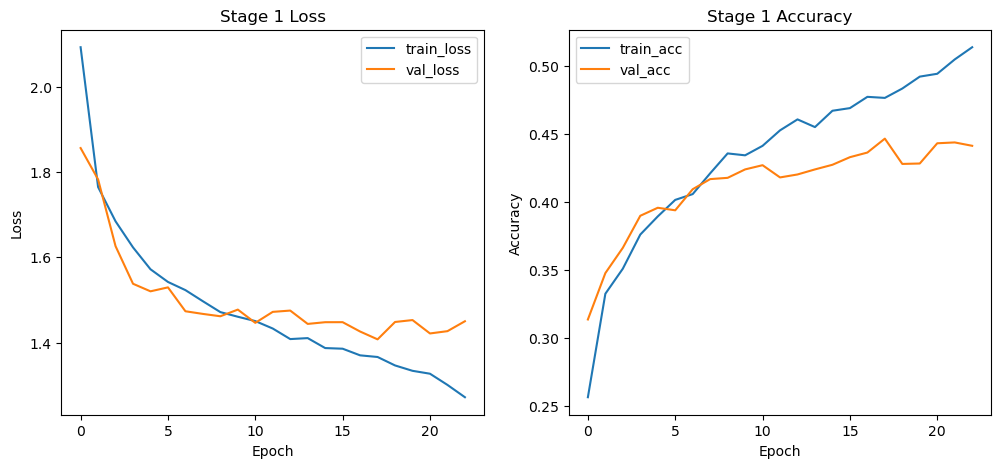

In [22]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_stage1.history['loss'], label='train_loss')
plt.plot(history_stage1.history['val_loss'], label='val_loss')
plt.title('Stage 1 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_stage1.history['accuracy'], label='train_acc')
plt.plot(history_stage1.history['val_accuracy'], label='val_acc')
plt.title('Stage 1 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [23]:
print(max(history_stage1.history["val_accuracy"]))
print(min(history_stage1.history["val_loss"]))

0.44675567746162415
1.4075534343719482


In [24]:
# STAGE 2 - Last 30 layers of base model fine-tuned
base_model.trainable = True

# Freeze all layers except last 100
for layer in base_model.layers[:-100]:
    layer.trainable = False

# Freeze batch normalization layers, to stabilize training and prevent overfitting when fine-tuning with small datasets
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# smaller learning rate to avoid large weights updates
# that can destroy pretrained features in base model
best_model.compile(
    optimizer=AdamW(
        learning_rate=5e-6,
        weight_decay=best_hp.get("l2_3")
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
callbacks_stage2 = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        SAVED_MODEL,
        monitor="val_loss",
        save_best_only=True
    ),
    CSVLogger("training_log_stage2.csv"),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5, #0.5
        patience=5
    )
]

In [26]:
# STAGE 2 - fine-tuning mobilenetv2 blocks (30layers)
start = time.time()
history_stage2 = best_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    class_weight=class_weights,
    callbacks=callbacks_stage2
)
end = time.time()
elapsed_time = end - start

print("Training time: ", time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))

Epoch 1/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 46s 101ms/step - accuracy: 0.4994 - loss: 1.3132 - val_accuracy: 0.4449 - val_loss: 1.4140 - learning_rate: 5.0000e-06
Epoch 2/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 37s 91ms/step - accuracy: 0.5048 - loss: 1.2821 - val_accuracy: 0.4536 - val_loss: 1.3670 - learning_rate: 5.0000e-06
Epoch 3/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 37s 91ms/step - accuracy: 0.5225 - loss: 1.2459 - val_accuracy: 0.4800 - val_loss: 1.3374 - learning_rate: 5.0000e-06
Epoch 4/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 37s 91ms/step - accuracy: 0.5293 - loss: 1.2332 - val_accuracy: 0.4716 - val_loss: 1.3453 - learning_rate: 5.0000e-06
Epoch 5/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 37s 91ms/step - accuracy: 0.5374 - loss: 1.2106 - val_accuracy: 0.4794 - val_loss: 1.3239 - learning_rate: 5.0000e-06
Epoch 6/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 37s 92ms/step - accuracy: 0.5513 - loss: 1.1981 - val_accuracy: 0.4800 - val_loss: 1.3255 - learning_rate: 5.0000e-06
Epoch 7/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 37s 92ms/st

In [27]:
print(max(history_stage2.history["val_accuracy"]))
print(max(history_stage2.history["accuracy"]))

print(min(history_stage2.history["val_loss"]))
print(max(history_stage2.history["loss"]))

0.5305805802345276
0.6887561082839966
1.2308318614959717
1.31321120262146


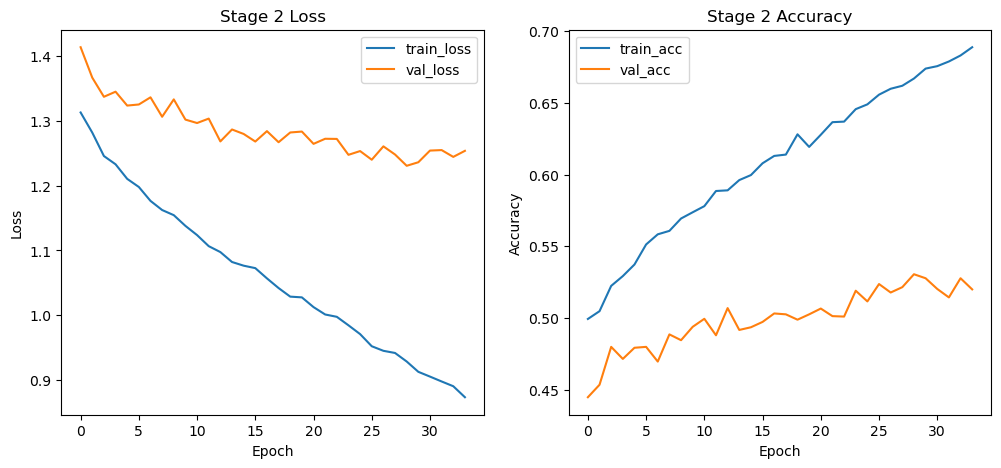

In [28]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_stage2.history['loss'], label='train_loss')
plt.plot(history_stage2.history['val_loss'], label='val_loss')
plt.title('Stage 2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_stage2.history['accuracy'], label='train_acc')
plt.plot(history_stage2.history['val_accuracy'], label='val_acc')
plt.title('Stage 2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [29]:
model = models.load_model(SAVED_MODEL)

In [30]:
test_loss, test_acc = best_model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc*100:.2f}%")

454/454 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.5309 - loss: 1.3890
Test Accuracy: 53.09%


454/454 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.5309 - loss: 1.3890
Test Accuracy: 53.09%, Test Loss: 1.3890
454/454 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step
Macro F1: 0.4867
              precision    recall  f1-score   support

       anger       0.47      0.35      0.40      1718
    contempt       0.41      0.64      0.50      1312
     disgust       0.39      0.34      0.36      1248
        fear       0.49      0.36      0.42      1664
       happy       0.70      0.89      0.78      2704
     neutral       0.66      0.68      0.67      2368
         sad       0.44      0.42      0.43      1584
    surprise       0.38      0.30      0.33      1920

    accuracy                           0.53     14518
   macro avg       0.49      0.50      0.49     14518
weighted avg       0.52      0.53      0.52     14518



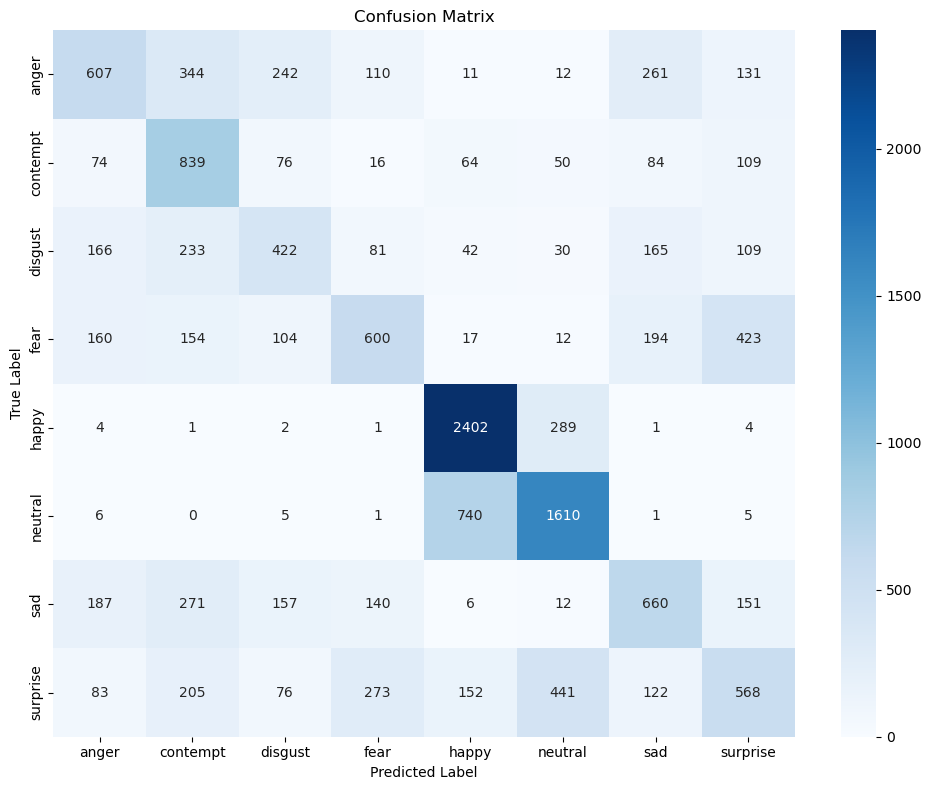

In [31]:
test_loss, test_acc = model.evaluate(test_dataset, verbose=1)
print(f"Test Accuracy: {test_acc*100:.2f}%, Test Loss: {test_loss:.4f}")

y_prob = model.predict(test_dataset, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.concatenate([y.numpy() for _, y in test_dataset], axis=0)

macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Macro F1: {macro_f1:.4f}")

print(classification_report(
    y_true,
    y_pred,
    target_names=CLASSES,
    zero_division=0
))

cm = confusion_matrix(
    y_true,
    y_pred,
    # labels=np.arange(num_classes),
    # normalize="true"
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

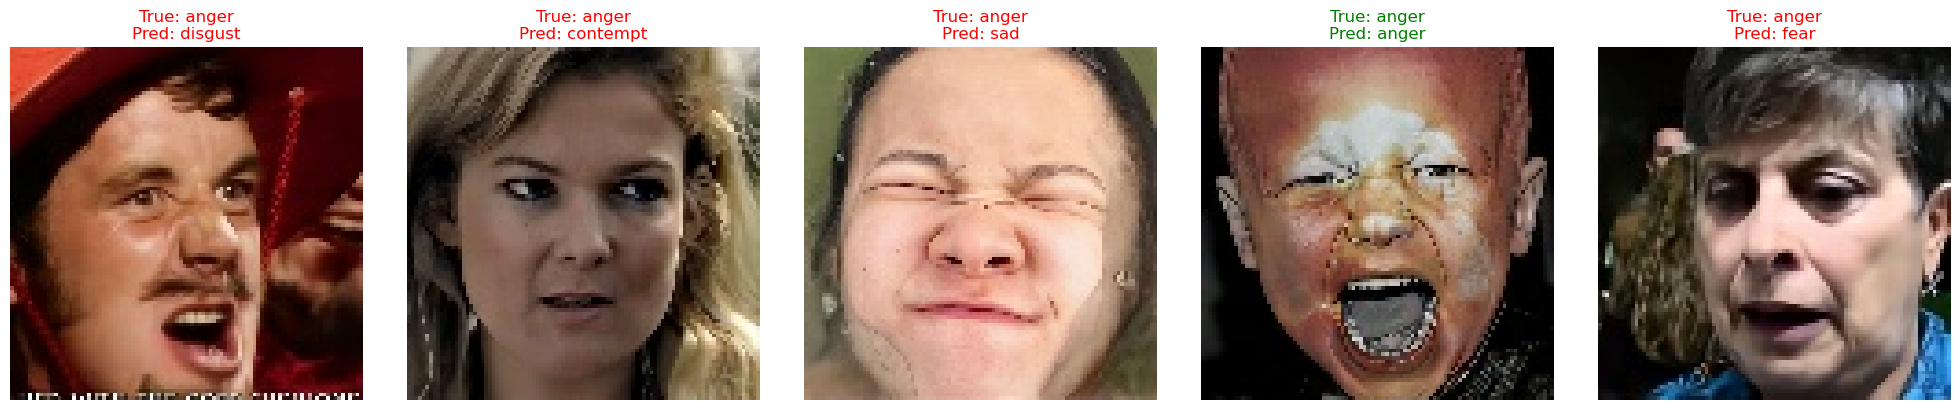

In [32]:
def predict_random_samples():

    # Get one batch
    images, labels = next(iter(test_dataset))

    # Random 5 images
    np.random.seed(RANDOM_SEED)
    indices = np.random.choice(len(images), 5, replace=False)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    for i, idx in enumerate(indices):

        img = images[idx]

        # True label
        true_idx = labels[idx].numpy()
        true_label = CLASSES[true_idx]

        # Prediction
        pred_prob = model.predict(
            np.expand_dims(img, axis=0),
            verbose=0
        )

        pred_idx = np.argmax(pred_prob)
        pred_label = CLASSES[pred_idx]

        # Plot image
        axes[i].imshow(img.numpy().astype("uint8"))
        axes[i].axis("off")

        # Color
        color = "green" if true_label == pred_label else "red"

        axes[i].set_title(
            f"True: {true_label}\nPred: {pred_label}",
            color=color
        )

    plt.tight_layout()
    plt.show()

predict_random_samples()

In [33]:
# Divide by 1024**2 to convert bytes to megabytes
size_mb = os.path.getsize(SAVED_MODEL) / (1024**2)

print(f"Model size: {size_mb:.2f} MB")

Model size: 29.70 MB


In [34]:
def measure_gpu_peak_memory(model, x, device="CPU:0"):
    # обнуляєм стати памяті
    tf.config.experimental.reset_memory_stats(device)
    # проганяєм модель на вході x (forward pass)
    y = model(tf.convert_to_tensor(x), training=False)
    # _ - placeholder для результату
    # y.numpy() - примусити TensorFlow виконати обчислення і оновити статистику пам'яті
    _ = y.numpy()
    # отримуємо інформацію про використання пам'яті
    info = tf.config.experimental.get_memory_info(device)
    # переводимо байти в мегабайти
    peak_mb = info["peak"] / (1024**2)
    current_mb = info["current"] / (1024**2)
    return peak_mb, current_mb

In [35]:
# тестуємо функцію на випадковому вході, який відповідає розміру зображення
input = tf.random.normal((1, 96, 96, 3))
peak_mb, current_mb = measure_gpu_peak_memory(
    model,
    input
)

print(f"CNN Peak Memory: {peak_mb:.2f} MB")
print(f"CNN Current Memory: {current_mb:.2f} MB")

CNN Peak Memory: 75.98 MB
CNN Current Memory: 67.34 MB


In [37]:
x_batch, y_batch = next(iter(test_dataset.take(1)))
x1 = x_batch[:1]

_ = model(x1, training=False)

start = time.perf_counter()
for _ in range(100):
    _ = model(x1, training=False)
end = time.perf_counter()

latency_ms = (end - start) / 100 * 1000
print(f"Latency per sample: {latency_ms:.3f} ms")

Latency per sample: 94.848 ms
